Linear Regression Part 1 - 4

In [2151]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline 

In [2152]:
#Randomly generate data in 2D plane
np.random.seed()  
N = 50           
X = np.random.rand(N, 1) * 10          
true_slope = 3
true_intercept = 1
Y = true_slope * X + true_intercept + np.random.randn(N, 1) * 1.5 #random 2D Plane Data with noise with real points being on the plane defined by y = 3x + 1
X_bias = np.c_[np.ones((N, 1)), X]  

In [2153]:
#determine the best fit line using linear regression formula [W = pseudoinverse(X)*Y]
W = np.linalg.pinv(X_bias) @ Y  # W = pseudoinverse(X) * Y
print("Our weights are:", W.flatten())

Our weights are: [0.5358678  3.04687572]


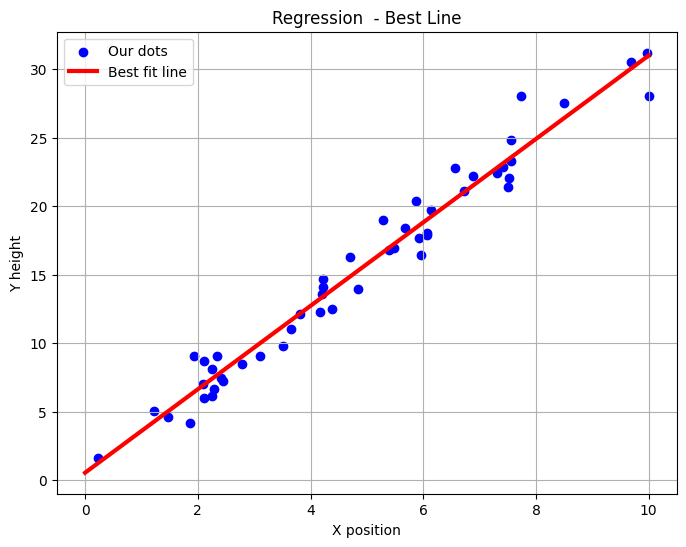

In [2154]:
#Draw the best fit line together with data points
plt.figure(figsize=(8,6))
plt.scatter(X, Y, color='blue', label='Our dots')
x_plot = np.linspace(0, 10, 100)
y_plot = W[0] + W[1] * x_plot
plt.plot(x_plot, y_plot, color='red', linewidth=3, label='Best fit line')
plt.legend()
plt.title("Regression  - Best Line")
plt.xlabel("X position")
plt.ylabel("Y height")
plt.grid(True)
plt.show()

In [2155]:
#What is your sum of square Error(Ein)
predictions = X_bias @ W
Ein = np.sum((predictions - Y) ** 2)
print("Sum of Square Error (Ein):", Ein)

Sum of Square Error (Ein): 91.51874009677078


Part 2: Linear Regression for Classification (The Separation Line)

In [2156]:
#Now generate random data as two separate clusters in 2D plane
np.random.seed()
N1 = 20
N2 = 20

cluster1 = np.random.randn(N1, 2) + np.array([2, 2])

cluster2 = np.random.randn(N2, 2) + np.array([7, 7])

X_clust = np.vstack([cluster1, cluster2])
labels = np.hstack([np.ones(N1), -np.ones(N2)]) 

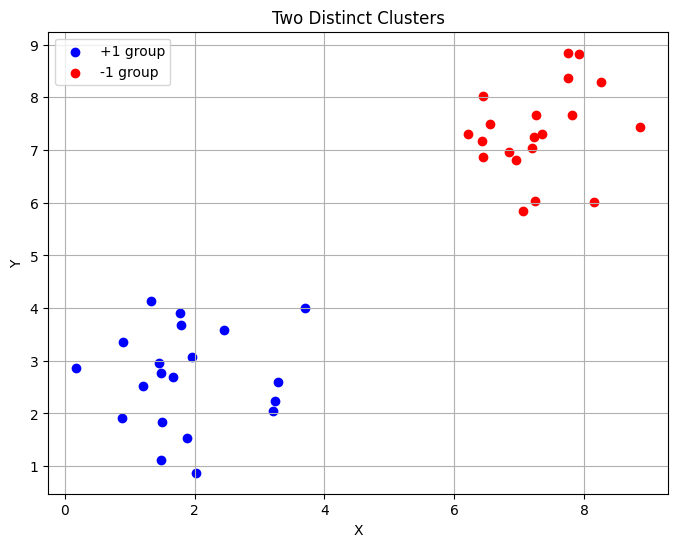

In [2157]:
#Scatter plot your data
plt.figure(figsize=(8,6))
plt.scatter(cluster1[:,0], cluster1[:,1], color='blue', label='+1 group')
plt.scatter(cluster2[:,0], cluster2[:,1], color='red', label='-1 group')
plt.legend()
plt.title("Two Distinct Clusters")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

In [2158]:
#Using linear regression for classification classify your data into two classes using the
#same formula given above.
X_clust = np.c_[np.ones((N1+N2, 1)), X_clust] 
W_class = np.linalg.pinv(X_clust) @ labels.reshape(-1, 1) # W = pseudoinverse(X) * Y
print("Classification weights:", W_class.flatten()) 

Classification weights: [ 1.75102975 -0.22201135 -0.14631064]


In [2159]:
predictions = np.sign(X_clust @ W_class)   # +1 or -1
correct = np.sum(predictions.flatten() == labels) #
accuracy = correct / len(labels) * 100 
print(f"Accuracy: {accuracy:.1f}%")

Accuracy: 100.0%


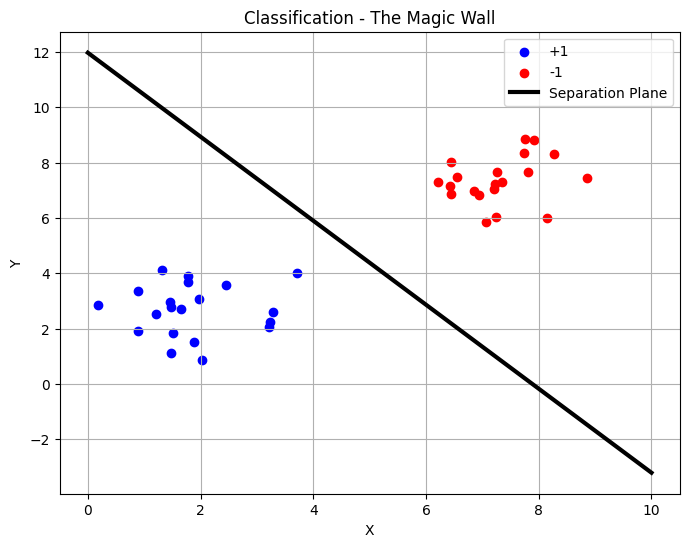

In [2160]:
#Draw the separation plane if possible.
plt.figure(figsize=(8,6))
plt.scatter(cluster1[:,0], cluster1[:,1], color='blue', label='+1')
plt.scatter(cluster2[:,0], cluster2[:,1], color='red', label='-1')

# The line equation is w0 + w1*x + w2*y = 0
w0, w1, w2 = W_class.flatten()
if abs(w2) > 1e-8:
    x_line = np.linspace(0, 10, 100)
    y_line = (-w0 - w1 * x_line) / w2
    plt.plot(x_line, y_line, color='black', linewidth=3, label='Separation Plane')
else:
    plt.axvline(x=-w0/w1, color='black', linewidth=3)

plt.legend()
plt.title("Classification - The Magic Wall")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

Show how linear regression for classification can improve pocket algorithm with
PLA.

In [2161]:
np.random.seed()
N = 100

# +1 
pos1 = np.random.randn(N//4, 2) * 0.3 + np.array([2, 0])
pos2 = np.random.randn(N//4, 2) * 0.3 + np.array([1, 1])

# -1 
neg1 = np.random.randn(N//4, 2) * 0.3 + np.array([0, 1])
neg2 = np.random.randn(N//4, 2) * 0.3 + np.array([1, 0])

X_non = np.vstack([pos1, pos2, neg1, neg2])
labels_non = np.hstack([np.ones(N//2), -np.ones(N//2)]) 

print("We Made Non Seperable Data where No straight line can keep all teams apart perfectly.")

We Made Non Seperable Data where No straight line can keep all teams apart perfectly.


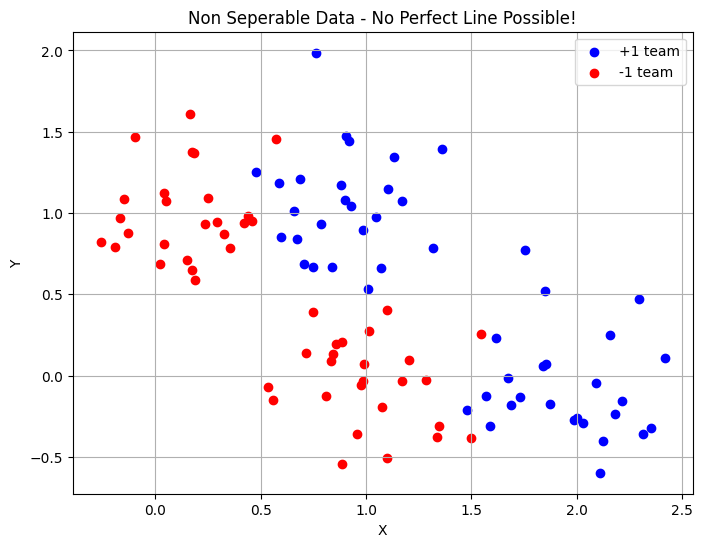

In [2162]:
plt.figure(figsize=(8,6))
plt.scatter(pos1[:,0], pos1[:,1], color='blue', label='+1 team')
plt.scatter(pos2[:,0], pos2[:,1], color='blue')
plt.scatter(neg1[:,0], neg1[:,1], color='red', label='-1 team')
plt.scatter(neg2[:,0], neg2[:,1], color='red')
plt.legend()
plt.title("Non Seperable Data - No Perfect Line Possible!")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

In [2163]:
X_bias_non = np.c_[np.ones((N, 1)), X_non]
W_reg = np.linalg.pinv(X_bias_non) @ labels_non.reshape(-1, 1)
print("Regression weights:", W_reg.flatten())

Regression weights: [-1.98341766  1.47562208  1.04669444]


In [2164]:
#  Pocket Algorithm
def pocket_algorithm(X, y, w_start=None, max_iter=200):
    if w_start is None:
        w = np.zeros((X.shape[1], 1))          # start with nothing
    else:
        w = w_start.copy()                     # start with smart regression wall!
    
    best_w = w.copy()
    
    def count_mistakes(w):
        preds = np.sign(X @ w).flatten()       # +1 or -1
        return np.sum(preds != y.flatten())
    
    best_errors = count_mistakes(w)
    
    for it in range(max_iter):
        for i in range(len(y)):
            if y[i] * (X[i] @ w) <= 0:         # wrong side!
                w += y[i] * X[i].reshape(-1, 1)
        
        current_errors = count_mistakes(w)
        if current_errors < best_errors:       # pocket remembers the best wall!
            best_w = w.copy()
            best_errors = current_errors
    return best_w, best_errors


w_pocket1, errors1 = pocket_algorithm(X_bias_non, labels_non.reshape(-1, 1), max_iter=1000)


w_pocket2, errors2 = pocket_algorithm(X_bias_non, labels_non.reshape(-1, 1), w_start=W_reg, max_iter=1000)

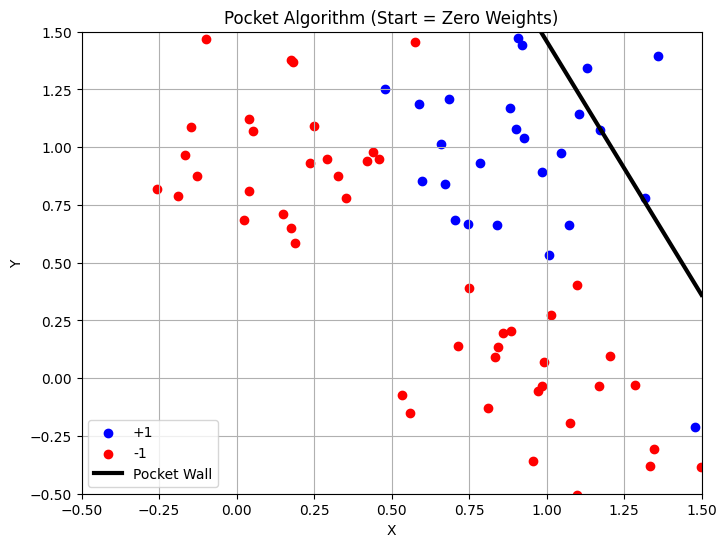

In [2165]:
plt.figure(figsize=(8,6))

# Plot data
plt.scatter(pos1[:,0], pos1[:,1], color='blue', label='+1')
plt.scatter(pos2[:,0], pos2[:,1], color='blue')
plt.scatter(neg1[:,0], neg1[:,1], color='red', label='-1')
plt.scatter(neg2[:,0], neg2[:,1], color='red')

# Decision boundary
w0, w1, w2 = w_pocket1.flatten()
x_line = np.linspace(-0.5, 1.5, 100)

if abs(w2) > 1e-8:
    y_line = (-w0 - w1 * x_line) / w2
    plt.plot(x_line, y_line, color='black', linewidth=3, label='Pocket Wall')
else:
    plt.axvline(x=-w0/w1, color='black', linewidth=3)

plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)

plt.legend()
plt.title("Pocket Algorithm (Start = Zero Weights)")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

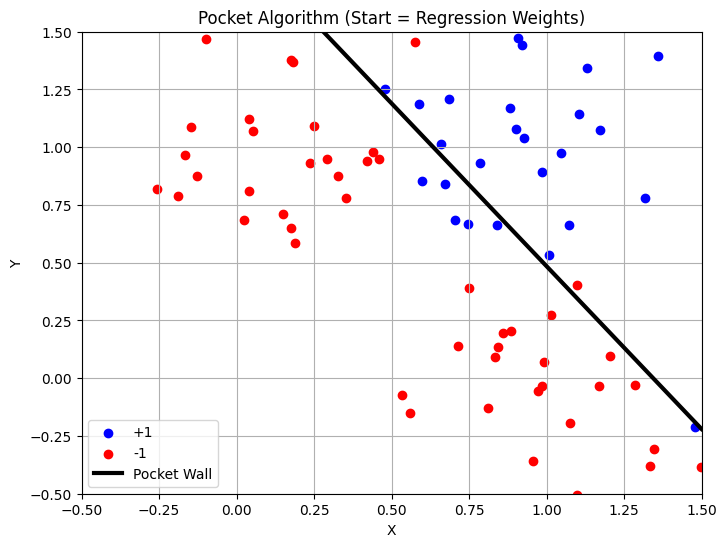

In [2166]:
plt.figure(figsize=(8,6))

# Plot data
plt.scatter(pos1[:,0], pos1[:,1], color='blue', label='+1')
plt.scatter(pos2[:,0], pos2[:,1], color='blue')
plt.scatter(neg1[:,0], neg1[:,1], color='red', label='-1')
plt.scatter(neg2[:,0], neg2[:,1], color='red')

# Decision boundary
w0, w1, w2 = w_pocket2.flatten()
x_line = np.linspace(-0.5, 1.5, 100)

if abs(w2) > 1e-8:
    y_line = (-w0 - w1 * x_line) / w2
    plt.plot(x_line, y_line, color='black', linewidth=3, label='Pocket Wall')
else:
    plt.axvline(x=-w0/w1, color='black', linewidth=3)

plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)

plt.legend()
plt.title("Pocket Algorithm (Start = Regression Weights)")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

In [2167]:
# Function to count mistakes
def count_mistakes(X, y, w):
    preds = np.sign(X @ w).flatten()
    return np.sum(preds != y.flatten())

errors_zero = count_mistakes(X_bias_non, labels_non.reshape(-1,1), w_pocket1)
errors_reg  = count_mistakes(X_bias_non, labels_non.reshape(-1,1), w_pocket2)

print("Pocket Algorithm Comparison")
print("---------------------------")
print(f"Start from ZERO weights mistakes:        {errors_zero}")
print(f"Start from REGRESSION weights mistakes:  {errors_reg}")

print()

if errors_reg < errors_zero:
    print("Starting from regression performed better.")
elif errors_reg > errors_zero:
    print("Starting from zero performed better.")
else:
    print("Both approaches performed the same.")

Pocket Algorithm Comparison
---------------------------
Start from ZERO weights mistakes:        25
Start from REGRESSION weights mistakes:  9

Starting from regression performed better.
